In [6]:
import pandas as pd

url = "https://raw.githubusercontent.com/Nayeli28Vilchis/Challenge_Telecom_X2/main/TelecomX_Data.json"

data = pd.read_json(url)

print(type(data))
data.head()

<class 'pandas.core.frame.DataFrame'>


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [7]:
df = pd.json_normalize(data.to_dict(orient="records"))

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [8]:
df.shape

(7267, 21)

In [9]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [10]:
df.drop(columns=['customerID'], inplace=True)

In [11]:
df.columns

Index(['Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

**Codificación de variables categóricas**

Para preparar los datos para los algoritmos de machine learning, las variables categóricas fueron transformadas a formato numérico utilizando la técnica de One-Hot Encoding. Este método crea nuevas columnas binarias que representan cada categoría posible de las variables originales. Se utilizó la función get_dummies() de pandas con el parámetro drop_first=True para evitar redundancia en las variables.

In [12]:
df.select_dtypes(include='object').columns

Index(['Churn', 'customer.gender', 'customer.Partner', 'customer.Dependents',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Total'],
      dtype='object')

In [13]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [14]:
df_encoded.head()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,Churn_No,Churn_Yes,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,phone.MultipleLines_No phone service,...,account.Charges.Total_995.35,account.Charges.Total_996.45,account.Charges.Total_996.85,account.Charges.Total_996.95,account.Charges.Total_997.65,account.Charges.Total_997.75,account.Charges.Total_998.1,account.Charges.Total_999.45,account.Charges.Total_999.8,account.Charges.Total_999.9
0,0,9,65.6,True,False,False,True,True,True,False,...,False,False,False,False,False,False,False,False,False,False
1,0,9,59.9,True,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,0,4,73.9,False,True,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,1,13,98.0,False,True,True,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,1,3,83.9,False,True,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Columns: 6561 entries, customer.SeniorCitizen to account.Charges.Total_999.9
dtypes: bool(6558), float64(1), int64(2)
memory usage: 45.6 MB


**Análisis del balance de clases**

Se analizó la distribución de la variable objetivo Churn para determinar si existe desbalance entre los clientes que cancelaron el servicio y aquellos que permanecieron activos. Los resultados muestran que la mayoría de los clientes se mantienen en la compañía, mientras que una menor proporción presenta evasión. Este desbalance es importante tenerlo en cuenta, ya que puede influir en el desempeño de los modelos predictivos.



In [16]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [18]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427


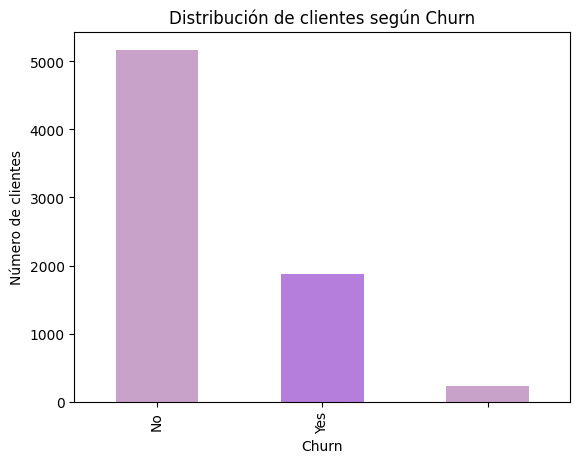

In [19]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar', color=['#C8A2C8', '#B57EDC'])

plt.title('Distribución de clientes según Churn')
plt.xlabel('Churn')
plt.ylabel('Número de clientes')

plt.show()

In [21]:
!pip install imbalanced-learn

In [23]:
df_encoded.columns

Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
       'Churn_No', 'Churn_Yes', 'customer.gender_Male', 'customer.Partner_Yes',
       'customer.Dependents_Yes', 'phone.PhoneService_Yes',
       'phone.MultipleLines_No phone service',
       ...
       'account.Charges.Total_995.35', 'account.Charges.Total_996.45',
       'account.Charges.Total_996.85', 'account.Charges.Total_996.95',
       'account.Charges.Total_997.65', 'account.Charges.Total_997.75',
       'account.Charges.Total_998.1', 'account.Charges.Total_999.45',
       'account.Charges.Total_999.8', 'account.Charges.Total_999.9'],
      dtype='object', length=6561)

In [24]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      7267 non-null   object 
 1   customer.gender            7267 non-null   object 
 2   customer.SeniorCitizen     7267 non-null   int64  
 3   customer.Partner           7267 non-null   object 
 4   customer.Dependents        7267 non-null   object 
 5   customer.tenure            7267 non-null   int64  
 6   phone.PhoneService         7267 non-null   object 
 7   phone.MultipleLines        7267 non-null   object 
 8   internet.InternetService   7267 non-null   object 
 9   internet.OnlineSecurity    7267 non-null   object 
 10  internet.OnlineBackup      7267 non-null   object 
 11  internet.DeviceProtection  7267 non-null   object 
 12  internet.TechSupport       7267 non-null   object 
 13  internet.StreamingTV       7267 non-null   objec

In [26]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [27]:
df_encoded.columns

Index(['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly',
       'account.Charges.Total', 'Churn_No', 'Churn_Yes',
       'customer.gender_Male', 'customer.Partner_Yes',
       'customer.Dependents_Yes', 'phone.PhoneService_Yes',
       'phone.MultipleLines_No phone service', 'phone.MultipleLines_Yes',
       'internet.InternetService_Fiber optic', 'internet.InternetService_No',
       'internet.OnlineSecurity_No internet service',
       'internet.OnlineSecurity_Yes',
       'internet.OnlineBackup_No internet service',
       'internet.OnlineBackup_Yes',
       'internet.DeviceProtection_No internet service',
       'internet.DeviceProtection_Yes',
       'internet.TechSupport_No internet service', 'internet.TechSupport_Yes',
       'internet.StreamingTV_No internet service', 'internet.StreamingTV_Yes',
       'internet.StreamingMovies_No internet service',
       'internet.StreamingMovies_Yes', 'account.Contract_One year',
       'account.Contract_Two year', 'acc

In [28]:
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

In [31]:
from imblearn.over_sampling import SMOTE

In [34]:
X.isnull().sum()

,0
customer.SeniorCitizen,0
customer.tenure,0
account.Charges.Monthly,0
account.Charges.Total,11
customer.gender_Male,0
customer.Partner_Yes,0
customer.Dependents_Yes,0
phone.PhoneService_Yes,0
phone.MultipleLines_No phone service,0
phone.MultipleLines_Yes,0


In [35]:
X = X.dropna()
y = y.loc[X.index]

In [36]:
X.isnull().sum()

,0
customer.SeniorCitizen,0
customer.tenure,0
account.Charges.Monthly,0
account.Charges.Total,0
customer.gender_Male,0
customer.Partner_Yes,0
customer.Dependents_Yes,0
phone.PhoneService_Yes,0
phone.MultipleLines_No phone service,0
phone.MultipleLines_Yes,0


In [37]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [38]:
pd.Series(y_resampled).value_counts()

,count
Churn_Yes,
False,5387
True,5387


**Normalización o Estandarización**

Se evaluó la necesidad de normalizar o estandarizar las variables numéricas del dataset.

In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_resampled)

In [41]:
X_scaled[:5]

array([[-0.39545014, -0.77663491, -0.08854248, -0.66459598, -1.17135937,
         0.99629422,  1.52725522,  0.29582745, -0.33873872, -0.96784544,
        -1.08267143, -0.44905532, -0.44905532, -0.62465474, -0.44905532,
         1.29310596, -0.44905532, -0.77916637, -0.44905532,  1.56133891,
        -0.44905532,  1.10996765, -0.44905532, -0.90109624,  2.0389928 ,
        -0.46123964,  0.65969222, -0.52802751, -0.96892513,  1.7958558 ],
       [-0.39545014, -0.77663491, -0.28706069, -0.6878755 ,  0.85370897,
        -1.00371956, -0.65476941,  0.29582745, -0.33873872,  1.03322283,
        -1.08267143, -0.44905532, -0.44905532, -0.62465474, -0.44905532,
        -0.77333183, -0.44905532, -0.77916637, -0.44905532, -0.64047594,
        -0.44905532, -0.90092716, -0.44905532,  1.10975937, -0.49043822,
        -0.46123964, -1.51585842, -0.52802751, -0.96892513,  1.7958558 ],
       [-0.39545014, -0.98541649,  0.20052791, -0.80749745,  0.85370897,
        -1.00371956, -0.65476941,  0.29582745, -0

In [42]:
X_scaled.shape

(10774, 30)

**Análisis de Correlación**

Se calculó la matriz de correlación entre las variables numéricas para identificar posibles relaciones entre ellas. Este análisis permite detectar variables que presentan una mayor relación con la cancelación de clientes (Churn). Las variables con mayor correlación positiva o negativa pueden ser consideradas candidatas importantes para los modelos predictivos, ya que pueden influir significativamente en el comportamiento de los clientes.

In [43]:
correlation_matrix = df_encoded.corr()

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

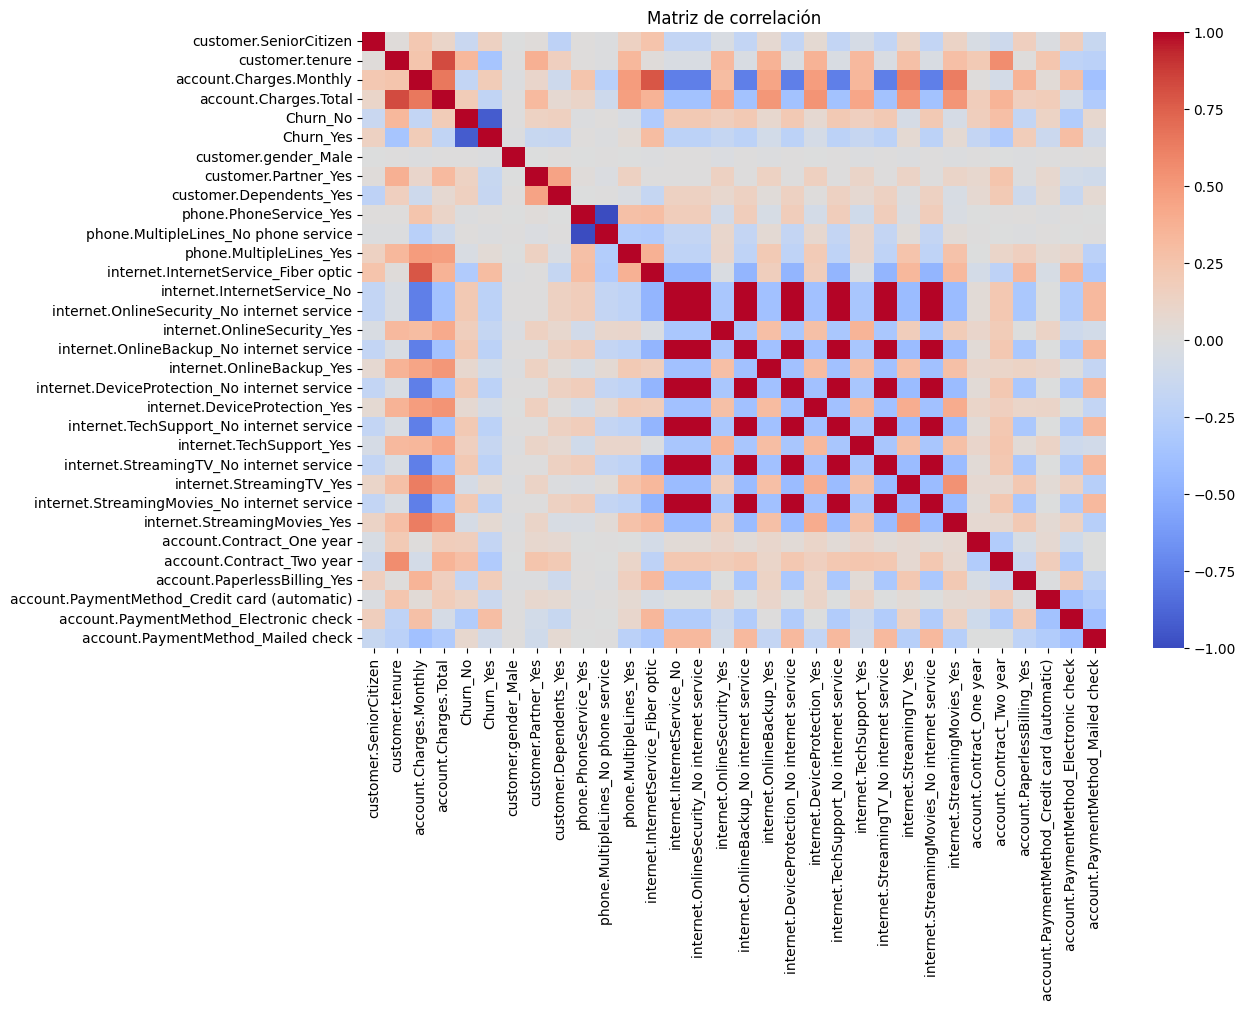

In [45]:
plt.figure(figsize=(12,8))

sns.heatmap(correlation_matrix, cmap="coolwarm")

plt.title("Matriz de correlación")
plt.show()

In [48]:
correlation_with_churn = df_encoded.corr()['Churn_Yes'].sort_values(ascending=False)

correlation_with_churn

,Churn_Yes
Churn_Yes,1.000000
internet.InternetService_Fiber optic,0.300949
account.PaymentMethod_Electronic check,0.294626
account.Charges.Monthly,0.189866
account.PaperlessBilling_Yes,0.186666
customer.SeniorCitizen,0.146733
internet.StreamingTV_Yes,0.062430
internet.StreamingMovies_Yes,0.060586
phone.MultipleLines_Yes,0.039343
phone.PhoneService_Yes,0.012571


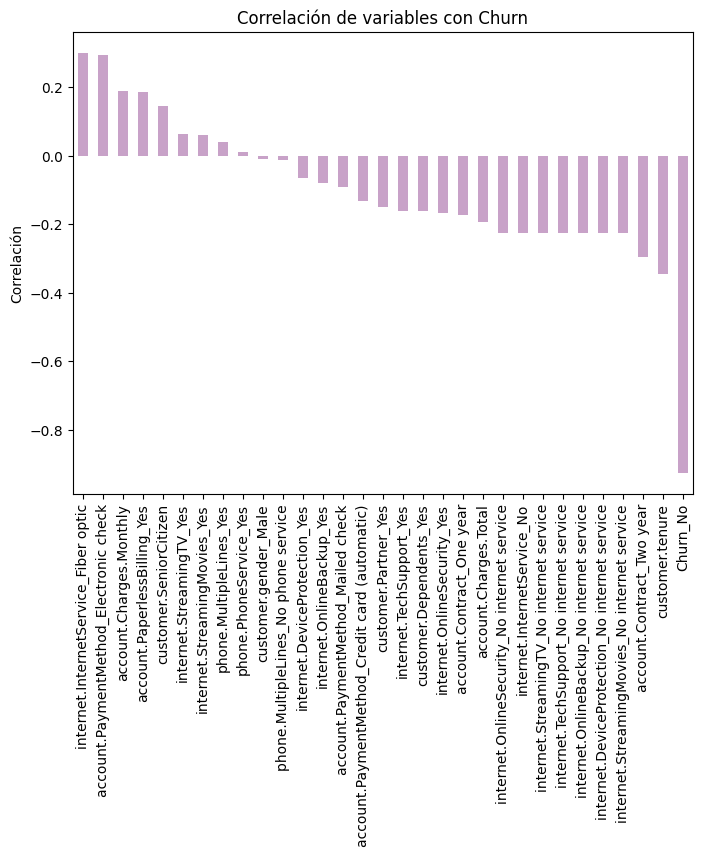

In [49]:
plt.figure(figsize=(8,6))

correlation_with_churn.drop('Churn_Yes').plot(kind='bar', color="#C8A2C8")

plt.title("Correlación de variables con Churn")
plt.ylabel("Correlación")
plt.show()

**Análisis**

**Relación entre variables numéricas y cancelación **

Se analizaron variables clave como el tiempo de contrato (tenure) y el gasto total de los clientes para identificar su relación con la cancelación del servicio. Mediante gráficos de tipo boxplot se observó que los clientes que cancelan el servicio tienden a tener un menor tiempo de permanencia y un menor gasto total en comparación con los clientes que permanecen activos. Estos resultados sugieren que la cancelación ocurre con mayor frecuencia en etapas tempranas de la relación con el cliente.

/tmp/ipykernel_979/1097896701.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Churn'], y=df['customer.tenure'], palette="pastel")


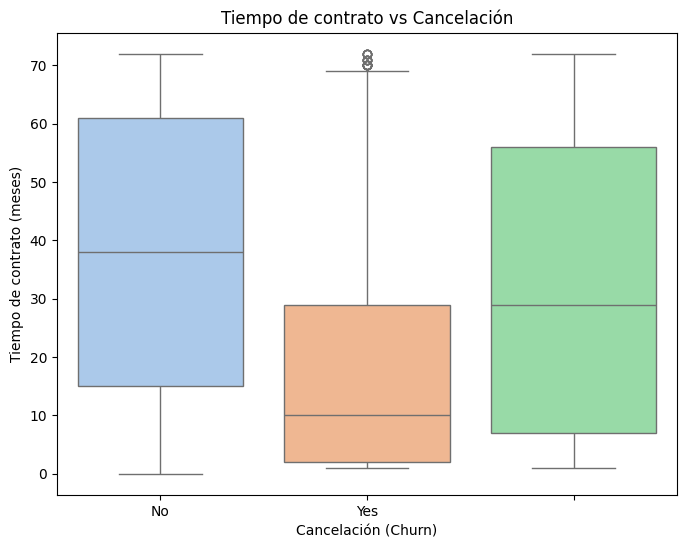

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(x=df['Churn'], y=df['customer.tenure'], palette="pastel")

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Cancelación (Churn)")
plt.ylabel("Tiempo de contrato (meses)")

plt.show()

/tmp/ipykernel_979/3007075171.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Churn'], y=df['account.Charges.Total'], palette="pastel")


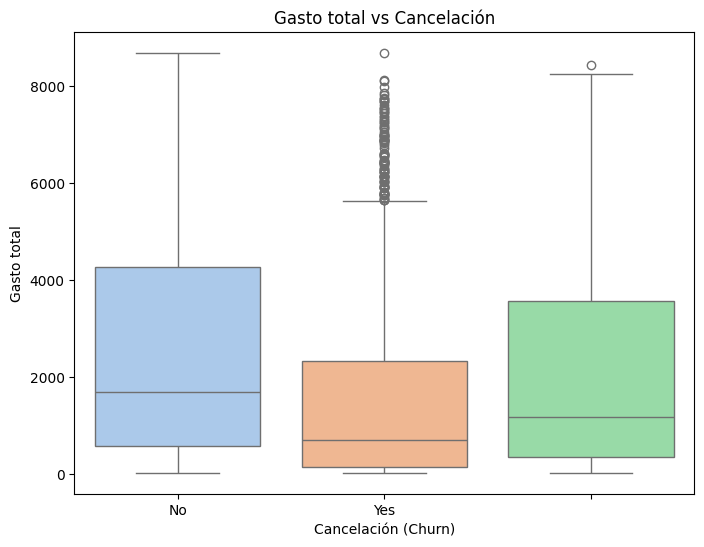

In [51]:
plt.figure(figsize=(8,6))

sns.boxplot(x=df['Churn'], y=df['account.Charges.Total'], palette="pastel")

plt.title("Gasto total vs Cancelación")
plt.xlabel("Cancelación (Churn)")
plt.ylabel("Gasto total")

plt.show()

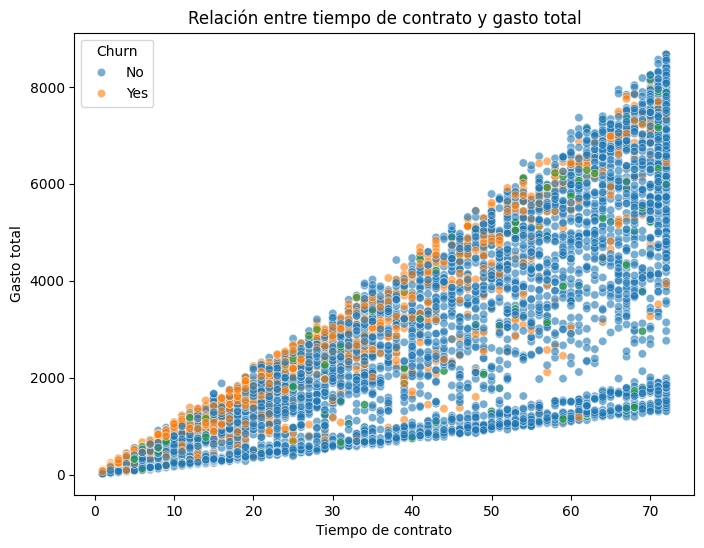

In [52]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['customer.tenure'],
    y=df['account.Charges.Total'],
    hue=df['Churn'],
    alpha=0.6
)

plt.title("Relación entre tiempo de contrato y gasto total")
plt.xlabel("Tiempo de contrato")
plt.ylabel("Gasto total")

plt.show()

**Separación de Datos**

Para evaluar el desempeño de los modelos de machine learning, el conjunto de datos se dividió en dos subconjuntos: uno para entrenamiento y otro para prueba. Se utilizó una división de 80% para entrenamiento y 20% para prueba, lo que permite entrenar el modelo con la mayor parte de los datos y posteriormente evaluar su capacidad de generalización utilizando datos que el modelo no ha visto previamente

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [55]:
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (8619, 30)
Datos de prueba: (2155, 30)


**Creación de Modelos**

Se desarrollaron dos modelos de clasificación para predecir la cancelación de clientes. El primer modelo fue una Regresión Logística, que requiere la normalización de las variables debido a que es sensible a la escala de los datos. Para este modelo se utilizó StandardScaler, lo que permite que todas las variables tengan una escala comparable y evita que variables con mayor magnitud influyan de manera desproporcionada en el entrenamiento.

El segundo modelo fue un Random Forest, un algoritmo basado en árboles de decisión que no depende de la escala de las variables, por lo que no requiere normalización. Este modelo permite capturar relaciones no lineales entre las variables y suele ofrecer buen desempeño en problemas de clasificación.



**Modelo 1: Regresión Logística (con datos normalizados)**

In [56]:
from sklearn.linear_model import LogisticRegression

In [57]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_scaled, y_resampled)

LogisticRegression(max_iter=1000)

In [60]:
y_pred_log = log_model.predict(X_scaled)

**Modelo 2: Random Forest**

In [58]:
from sklearn.ensemble import RandomForestClassifier

In [59]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [61]:
y_pred_rf = rf_model.predict(X_test)

In [62]:
from sklearn.metrics import classification_report

In [69]:
print("Resultados Regresión Logística")
print(classification_report(y_resampled, y_pred_log))

Resultados Regresión Logística
              precision    recall  f1-score   support

       False       0.83      0.83      0.83      5387
        True       0.83      0.84      0.83      5387

    accuracy                           0.83     10774
   macro avg       0.83      0.83      0.83     10774
weighted avg       0.83      0.83      0.83     10774



In [70]:
print("Resultados Random Forest")
print(classification_report(y_test, y_pred_rf))

Resultados Random Forest
              precision    recall  f1-score   support

       False       0.87      0.84      0.86      1094
        True       0.84      0.87      0.86      1061

    accuracy                           0.86      2155
   macro avg       0.86      0.86      0.86      2155
weighted avg       0.86      0.86      0.86      2155



**Evaluación de los Modelos**

Se evaluaron los modelos de Regresión Logística y Random Forest utilizando diferentes métricas de clasificación, incluyendo exactitud (accuracy), precisión, recall y F1-score. Estas métricas permiten evaluar el desempeño del modelo en la predicción de cancelación de clientes. Además, se utilizó la matriz de confusión para analizar la distribución de predicciones correctas e incorrectas.

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [72]:
y_pred_log = log_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


**Regresión Logística**

In [73]:
print("Evaluación - Regresión Logística")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

Evaluación - Regresión Logística
Accuracy: 0.34477958236658934
Precision: 0.3872832369942196
Recall: 0.5683317624882187
F1-score: 0.46065699006875477


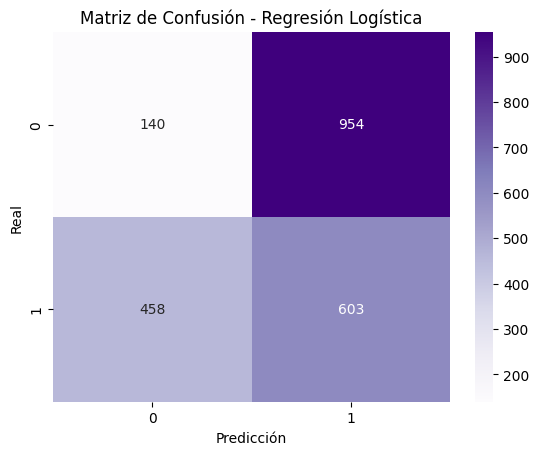

In [74]:
cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt='d', cmap="Purples")

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

**Random Forest**

In [75]:
y_pred_rf = rf_model.predict(X_test)

In [76]:
print("Evaluación - Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

Evaluación - Random Forest
Accuracy: 0.8552204176334107
Precision: 0.8426349496797805
Recall: 0.8680490103675778
F1-score: 0.8551532033426184


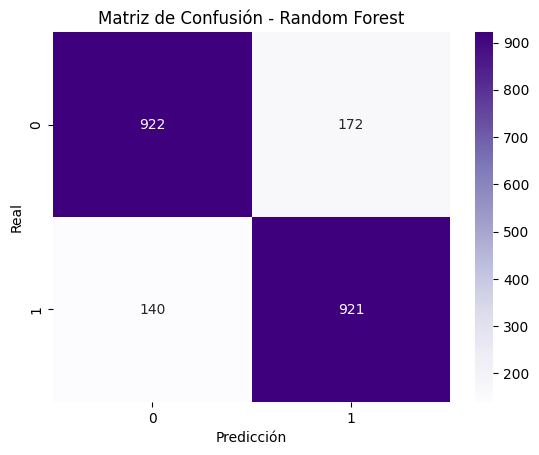

In [77]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap="Purples")

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

**Análisis de la Importancia de las Variables**

Para comprender qué factores influyen más en la cancelación de clientes, se analizó la importancia de las variables en los modelos utilizados. En el caso de la Regresión Logística, se examinaron los coeficientes del modelo, los cuales indican cómo cada variable contribuye a aumentar o disminuir la probabilidad de cancelación. Por otro lado, en el modelo Random Forest se analizó la importancia de las variables calculada durante el entrenamiento, basada en la reducción de impureza en los árboles de decisión.

In [78]:
import pandas as pd

coeficientes = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': log_model.coef_[0]
})

coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=False)

coeficientes.head(10)

,Variable,Coeficiente
10,internet.InternetService_Fiber optic,4.084151
7,phone.PhoneService_Yes,3.090303
8,phone.MultipleLines_No phone service,1.820866
23,internet.StreamingMovies_Yes,1.543745
21,internet.StreamingTV_Yes,1.531082
3,account.Charges.Total,1.334844
9,phone.MultipleLines_Yes,0.925636
17,internet.DeviceProtection_Yes,0.712724
15,internet.OnlineBackup_Yes,0.680292
28,account.PaymentMethod_Electronic check,0.607714


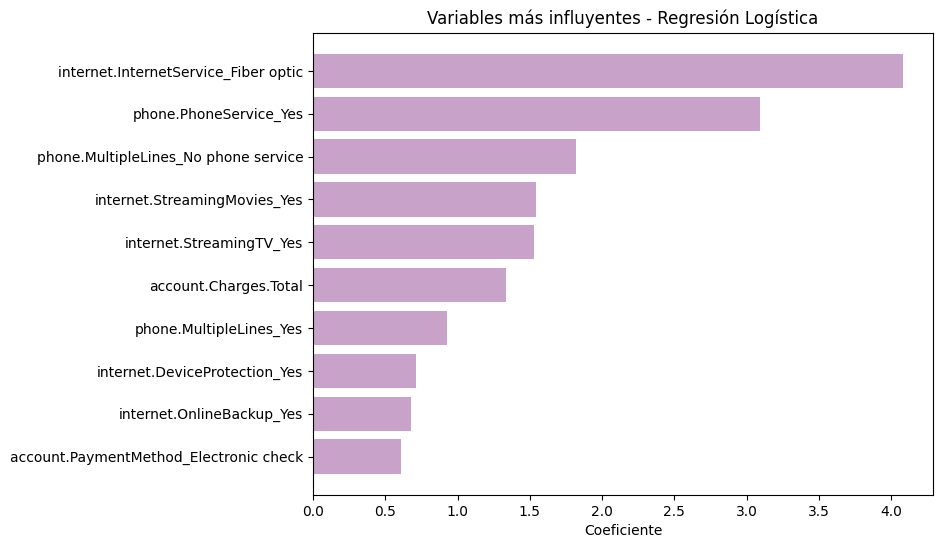

In [79]:
import matplotlib.pyplot as plt

top_coef = coeficientes.head(10)

plt.figure(figsize=(8,6))

plt.barh(top_coef['Variable'], top_coef['Coeficiente'], color='#C8A2C8')

plt.title("Variables más influyentes - Regresión Logística")
plt.xlabel("Coeficiente")
plt.gca().invert_yaxis()

plt.show()

In [80]:
importances = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf_model.feature_importances_
})

importances = importances.sort_values(by='Importancia', ascending=False)

importances.head(10)

,Variable,Importancia
3,account.Charges.Total,0.165770
1,customer.tenure,0.153305
2,account.Charges.Monthly,0.139290
28,account.PaymentMethod_Electronic check,0.099054
10,internet.InternetService_Fiber optic,0.051939
25,account.Contract_Two year,0.042839
26,account.PaperlessBilling_Yes,0.038139
4,customer.gender_Male,0.024512
9,phone.MultipleLines_Yes,0.023478
24,account.Contract_One year,0.022855


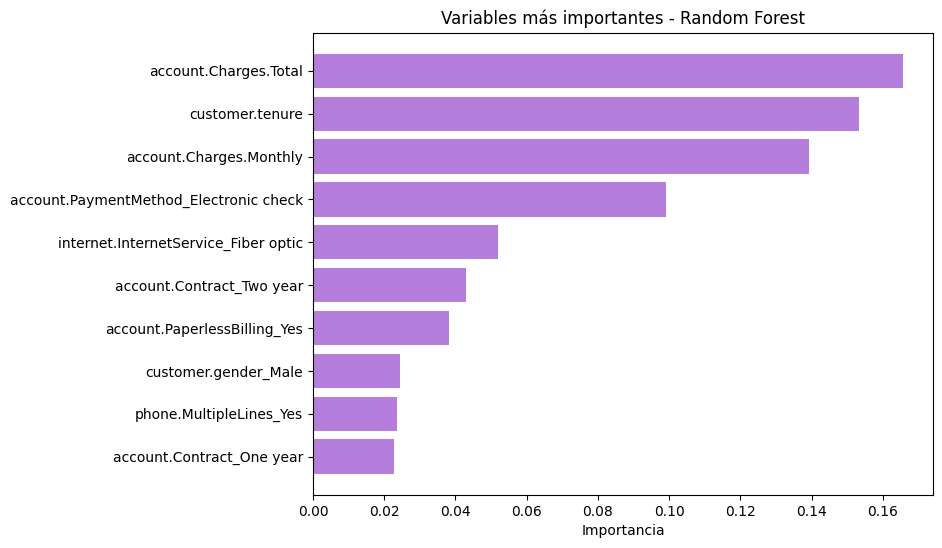

In [81]:
top_importances = importances.head(10)

plt.figure(figsize=(8,6))

plt.barh(top_importances['Variable'], top_importances['Importancia'], color='#B57EDC')

plt.title("Variables más importantes - Random Forest")
plt.xlabel("Importancia")

plt.gca().invert_yaxis()

plt.show()

📊 **Conclusión del análisis**

En este proyecto se analizaron datos de clientes de una empresa de telecomunicaciones para entender los factores que influyen en la cancelación del servicio. A través del análisis exploratorio y de modelos de machine learning, se identificó que variables como el tipo de contrato, el tiempo de permanencia del cliente y los cargos mensuales tienen una relación importante con la cancelación.

Los resultados muestran que los clientes con contratos mes a mes y con menor tiempo en la empresa tienen mayor probabilidad de cancelar el servicio. Entre los modelos utilizados, Random Forest mostró un mejor desempeño para predecir la cancelación, mientras que la Regresión Logística permitió interpretar mejor la influencia de las variables.



💡 **Recomendaciones**

Con base en estos resultados, la empresa podría implementar estrategias como incentivar contratos de mayor duración, prestar mayor atención a los clientes nuevos y revisar la estructura de precios de los planes para mejorar la retención de clientes.

🧠 **Conclusión final**

Este análisis muestra cómo los datos pueden ayudar a entender mejor el comportamiento de los clientes y apoyar la toma de decisiones en una empresa. Utilizando herramientas de análisis de datos y machine learning, es posible identificar patrones y diseñar estrategias para mejorar la retención de clientes.